Electricity Consumption Analytics Project

Objective
Analyze electricity consumption data using Python and generate insights through data cleaning, processing, analysis, and visualization.

Part 1- Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv("powerconsumption.csv")

In [3]:
df.head()

,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Datetime                52416 non-null  str    
 1   Temperature             52416 non-null  float64
 2   Humidity                52416 non-null  float64
 3   WindSpeed               52416 non-null  float64
 4   GeneralDiffuseFlows     52416 non-null  float64
 5   DiffuseFlows            52416 non-null  float64
 6   PowerConsumption_Zone1  52416 non-null  float64
 7   PowerConsumption_Zone2  52416 non-null  float64
 8   PowerConsumption_Zone3  52416 non-null  float64
dtypes: float64(8), str(1)
memory usage: 3.6 MB


In [5]:
df.shape

(52416, 9)

Part 2 - Data Cleaning

In [6]:
df.isnull().sum()

Datetime                  0
Temperature               0
Humidity                  0
WindSpeed                 0
GeneralDiffuseFlows       0
DiffuseFlows              0
PowerConsumption_Zone1    0
PowerConsumption_Zone2    0
PowerConsumption_Zone3    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df=df.drop_duplicates()

In [4]:
df['Datetime']=pd.to_datetime(df['Datetime'])

In [10]:
df.dtypes

Datetime                  datetime64[us]
Temperature                      float64
Humidity                         float64
WindSpeed                        float64
GeneralDiffuseFlows              float64
DiffuseFlows                     float64
PowerConsumption_Zone1           float64
PowerConsumption_Zone2           float64
PowerConsumption_Zone3           float64
dtype: object

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Datetime                52416 non-null  datetime64[us]
 1   Temperature             52416 non-null  float64       
 2   Humidity                52416 non-null  float64       
 3   WindSpeed               52416 non-null  float64       
 4   GeneralDiffuseFlows     52416 non-null  float64       
 5   DiffuseFlows            52416 non-null  float64       
 6   PowerConsumption_Zone1  52416 non-null  float64       
 7   PowerConsumption_Zone2  52416 non-null  float64       
 8   PowerConsumption_Zone3  52416 non-null  float64       
dtypes: datetime64[us](1), float64(8)
memory usage: 3.6 MB


In [12]:
df.describe()

,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
count,52416,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000
mean,2017-07-01 23:55:00,18.810024,68.259518,1.959489,182.696614,75.028022,32344.970564,21042.509082,17835.406218
min,2017-01-01 00:00:00,3.247000,11.340000,0.050000,0.004000,0.011000,13895.696200,8560.081466,5935.174070
25%,2017-04-01 23:57:30,14.410000,58.310000,0.078000,0.062000,0.122000,26310.668692,16980.766032,13129.326630
50%,2017-07-01 23:55:00,18.780000,69.860000,0.086000,5.035500,4.456000,32265.920340,20823.168405,16415.117470
75%,2017-09-30 23:52:30,22.890000,81.400000,4.915000,319.600000,101.000000,37309.018185,24713.717520,21624.100420
max,2017-12-30 23:50:00,40.010000,94.800000,6.483000,1163.000000,936.000000,52204.395120,37408.860760,47598.326360
std,NaN,5.815476,15.551177,2.348862,264.400960,124.210949,7130.562564,5201.465892,6622.165099


In [13]:
df.isnull().sum()

Datetime                  0
Temperature               0
Humidity                  0
WindSpeed                 0
GeneralDiffuseFlows       0
DiffuseFlows              0
PowerConsumption_Zone1    0
PowerConsumption_Zone2    0
PowerConsumption_Zone3    0
dtype: int64

Part 3 - Data Processing

In [6]:
df['Total_Power_Consumption'] = (
    df['PowerConsumption_Zone1']
    + df['PowerConsumption_Zone2']
    + df['PowerConsumption_Zone3']
)
df.head()

,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3,Total_Power_Consumption
0,2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,70425.53544
1,2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,69320.84387
2,2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,67803.22193
3,2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,65489.23209
4,2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,63650.44627


In [10]:
df['Date'] = df['Datetime'].dt.date
df['Time'] = df['Datetime'].dt.time
df['Hour'] = df['Datetime'].dt.hour
df['Month'] = df['Datetime'].dt.to_period('M').astype(str)

In [8]:
df.head()

,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3,Total_Power_Consumption,Date,Time,Hour,Month
0,2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,70425.53544,2017-01-01,00:00:00,0,2017-01
1,2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,69320.84387,2017-01-01,00:10:00,0,2017-01
2,2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,67803.22193,2017-01-01,00:20:00,0,2017-01
3,2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,65489.23209,2017-01-01,00:30:00,0,2017-01
4,2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,63650.44627,2017-01-01,00:40:00,0,2017-01


In [9]:
print(df[['PowerConsumption_Zone1',
          'PowerConsumption_Zone2',
          'PowerConsumption_Zone3',
          'Total_Power_Consumption']].head())

   PowerConsumption_Zone1  PowerConsumption_Zone2  PowerConsumption_Zone3  \
0             34055.69620             16128.87538             20240.96386   
1             29814.68354             19375.07599             20131.08434   
2             29128.10127             19006.68693             19668.43373   
3             28228.86076             18361.09422             18899.27711   
4             27335.69620             17872.34043             18442.40964   

   Total_Power_Consumption  
0              70425.53544  
1              69320.84387  
2              67803.22193  
3              65489.23209  
4              63650.44627  


In [10]:
print(df[['Total_Power_Consumption', 'Hour']].describe())

       Total_Power_Consumption          Hour
count             52416.000000  52416.000000
mean              71222.885864     11.500000
std               17143.138964      6.922253
min               36785.039739      0.000000
25%               56499.074640      5.750000
50%               69788.790940     11.500000
75%               83749.172310     17.250000
max              134208.145950     23.000000


Part 4 - Data Analysis

Total Power Consumption

In [11]:
total_consumption = df['Total_Power_Consumption'].sum()

print("Total Power Consumption:", total_consumption)

Total Power Consumption: 3733218785.462324


Highest Consumption Hour

In [12]:
hourly_consumption = df.groupby('Hour')['Total_Power_Consumption'].sum()

highest_consumption_hour = hourly_consumption.idxmax()
highest_hour_consumption = hourly_consumption.max()

print("Highest Consumption Hour:", highest_consumption_hour)
print("Total Consumption at that Hour:", highest_hour_consumption)

Highest Consumption Hour: 20
Total Consumption at that Hour: 214113048.4808


Highest Consumption Zone

In [13]:
zone_consumption = {
    'Zone 1': df['PowerConsumption_Zone1'].sum(),
    'Zone 2': df['PowerConsumption_Zone2'].sum(),
    'Zone 3': df['PowerConsumption_Zone3'].sum()
}

highest_zone = max(zone_consumption, key=zone_consumption.get)
highest_zone_consumption = zone_consumption[highest_zone]

print("Highest Consumption Zone:", highest_zone)
print("Total Consumption:", highest_zone_consumption)

Highest Consumption Zone: Zone 1
Total Consumption: 1695393977.06092


Zone Analysis

In [14]:
print("Zone 1 Consumption:", df['PowerConsumption_Zone1'].sum())
print("Zone 2 Consumption:", df['PowerConsumption_Zone2'].sum())
print("Zone 3 Consumption:", df['PowerConsumption_Zone3'].sum())

Zone 1 Consumption: 1695393977.06092
Zone 2 Consumption: 1102964156.058971
Zone 3 Consumption: 934860652.342433


Monthly Consumption Analysis

In [15]:
monthly_consumption = df.groupby('Month')['Total_Power_Consumption'].sum()

print(monthly_consumption)

Month
2017-01    3.043244e+08
2017-02    2.705817e+08
2017-03    2.971274e+08
2017-04    2.911546e+08
2017-05    3.124550e+08
2017-06    3.270560e+08
2017-07    3.936067e+08
2017-08    3.827447e+08
2017-09    2.959196e+08
2017-10    3.015912e+08
2017-11    2.812539e+08
2017-12    2.754036e+08
Name: Total_Power_Consumption, dtype: float64


Part 5 - Data Visualization

Bar Chart-Power Consumption by Zone

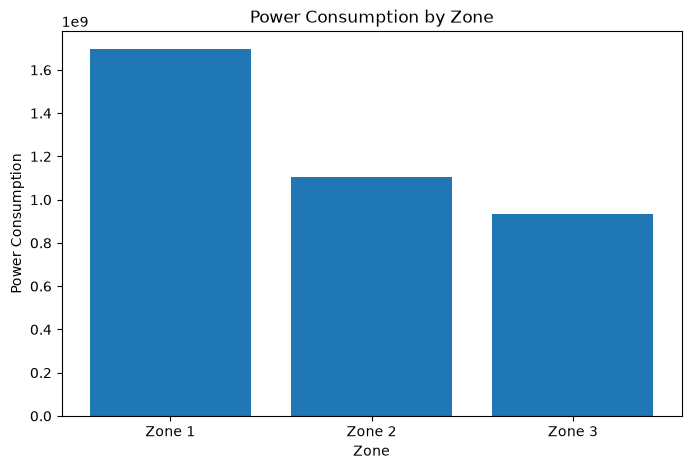

In [16]:
zone_names = ['Zone 1', 'Zone 2', 'Zone 3']

zone_values = [
    df['PowerConsumption_Zone1'].sum(),
    df['PowerConsumption_Zone2'].sum(),
    df['PowerConsumption_Zone3'].sum()
]

plt.figure(figsize=(8, 5))
plt.bar(zone_names, zone_values)

plt.xlabel('Zone')
plt.ylabel('Power Consumption')
plt.title('Power Consumption by Zone')

plt.show()

Pie Chart - Zone Contribution

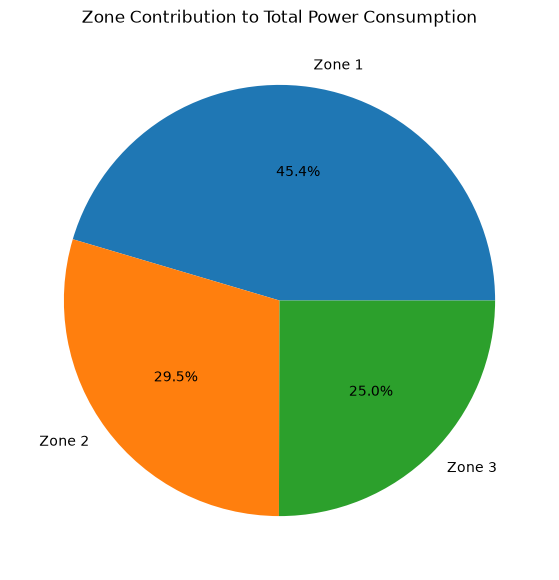

In [5]:
zone_names = ['Zone 1', 'Zone 2', 'Zone 3']

zone_values = [
    df['PowerConsumption_Zone1'].sum(),
    df['PowerConsumption_Zone2'].sum(),
    df['PowerConsumption_Zone3'].sum()
]

plt.figure(figsize=(7, 7))
plt.pie(zone_values, labels=zone_names, autopct='%1.1f%%')

plt.title('Zone Contribution to Total Power Consumption')

plt.show()

Line chart - Monthly Consumption Trend

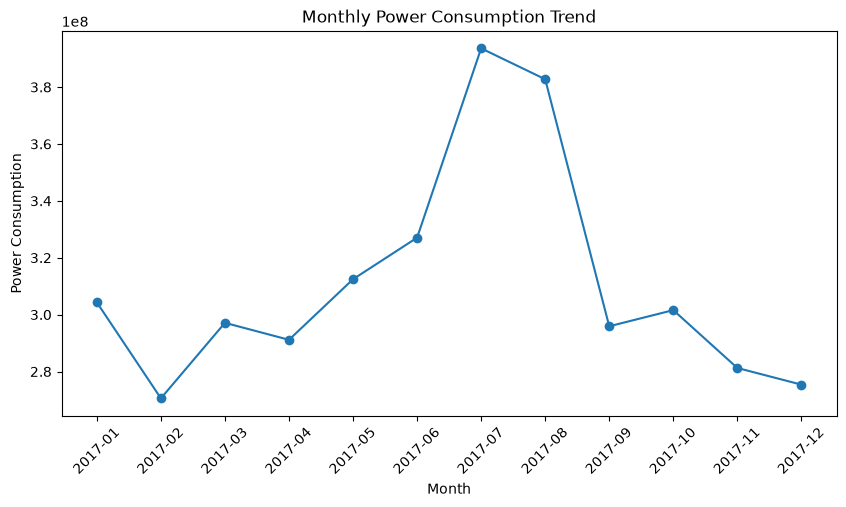

In [8]:
# Create required columns again
df['Datetime'] = pd.to_datetime(df['Datetime'])

df['Total_Power_Consumption'] = (
    df['PowerConsumption_Zone1']
    + df['PowerConsumption_Zone2']
    + df['PowerConsumption_Zone3']
)

df['Month'] = df['Datetime'].dt.to_period('M').astype(str)

# Monthly consumption
monthly_consumption = df.groupby('Month')['Total_Power_Consumption'].sum()

# Line chart
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_consumption.index,
    monthly_consumption.values,
    marker='o'
)

plt.xlabel('Month')
plt.ylabel('Power Consumption')
plt.title('Monthly Power Consumption Trend')

plt.xticks(rotation=45)

plt.show()

In [11]:
print("Total Power Consumption:", df['Total_Power_Consumption'].sum())

print("\nZone Consumption:")
print(df[['PowerConsumption_Zone1',
          'PowerConsumption_Zone2',
          'PowerConsumption_Zone3']].sum())

print("\nHighest Consumption Hour:")
hourly_consumption = df.groupby('Hour')['Total_Power_Consumption'].sum()
print(hourly_consumption.idxmax(), "Hour")

print("\nMonthly Consumption:")
monthly_consumption = df.groupby('Month')['Total_Power_Consumption'].sum()
print(monthly_consumption)

print("\nHighest Consumption Month:")
print(monthly_consumption.idxmax())

Total Power Consumption: 3733218785.462324

Zone Consumption:
PowerConsumption_Zone1    1.695394e+09
PowerConsumption_Zone2    1.102964e+09
PowerConsumption_Zone3    9.348607e+08
dtype: float64

Highest Consumption Hour:
20 Hour

Monthly Consumption:
Month
2017-01    3.043244e+08
2017-02    2.705817e+08
2017-03    2.971274e+08
2017-04    2.911546e+08
2017-05    3.124550e+08
2017-06    3.270560e+08
2017-07    3.936067e+08
2017-08    3.827447e+08
2017-09    2.959196e+08
2017-10    3.015912e+08
2017-11    2.812539e+08
2017-12    2.754036e+08
Name: Total_Power_Consumption, dtype: float64

Highest Consumption Month:
2017-07


Part 6 - Business Insights

1. The total power consumption across all three zones is approximately 3.73 billion units.

2. Zone 1 has the highest overall power consumption at approximately 1.70 billion units, making it the largest consuming zone.

3. Zone 2 is the second-highest consuming zone with approximately 1.10 billion units.

4. Zone 3 has the lowest overall consumption among the three zones, with approximately 0.93 billion units.

5. The highest electricity consumption occurs at 8:00 PM (Hour 20), indicating that evening hours have a high demand for electricity.

6. July 2017 recorded the highest monthly power consumption at approximately 393.61 million units.

7. February 2017 recorded the lowest monthly power consumption at approximately 270.58 million units.

8. Power consumption varies significantly across different months, showing seasonal changes in electricity demand.

Part 7 - Recommendations

1. Focus on Zone 1 for energy-saving measures because it has the highest overall power consumption.

2. Monitor electricity usage around 8:00 PM and consider load management or scheduling high-power activities outside peak hours where possible.

3. Prepare for high-consumption months such as July by planning energy requirements and performing regular equipment maintenance.

4. Analyze the reasons for monthly consumption variations and identify opportunities to reduce unnecessary power usage.

5. Continuously monitor power consumption across all three zones to identify unusual increases and improve energy efficiency.

Part 8 - Bonus Analysis

Top 3 Highest Consumption Periods

In [ ]:
df['Datetime'] = pd.to_datetime(df['Datetime'])

df['Total_Power_Consumption'] = (
    df['PowerConsumption_Zone1']
    + df['PowerConsumption_Zone2']
    + df['PowerConsumption_Zone3']
)

top_3_periods = df.nlargest(3, 'Total_Power_Consumption')[
    ['Datetime', 'Total_Power_Consumption']
]

print("Top 3 Highest Consumption Periods:")
print(top_3_periods)

Top 3 Highest Consumption Periods:
                 Datetime  Total_Power_Consumption
29497 2017-07-24 20:10:00             134208.14595
29498 2017-07-24 20:20:00             133914.02715
29929 2017-07-27 20:10:00             133675.18577


Average Daily Consumption

In [ ]:
df['Date'] = df['Datetime'].dt.date

daily_consumption = df.groupby('Date')['Total_Power_Consumption'].sum()

average_daily_consumption = daily_consumption.mean()

print("Average Daily Power Consumption:", average_daily_consumption)

Average Daily Power Consumption: 10256095.564456934


Weather Analysis

In [ ]:
weather_correlation = df[
    ['Temperature',
     'Humidity',
     'WindSpeed',
     'Total_Power_Consumption']
].corr()

print("Weather and Power Consumption Correlation:")
print(weather_correlation['Total_Power_Consumption'])

Weather and Power Consumption Correlation:
Temperature                0.488238
Humidity                  -0.299059
WindSpeed                  0.221706
Total_Power_Consumption    1.000000
Name: Total_Power_Consumption, dtype: float64


Temperature vs Power Consumption Chart

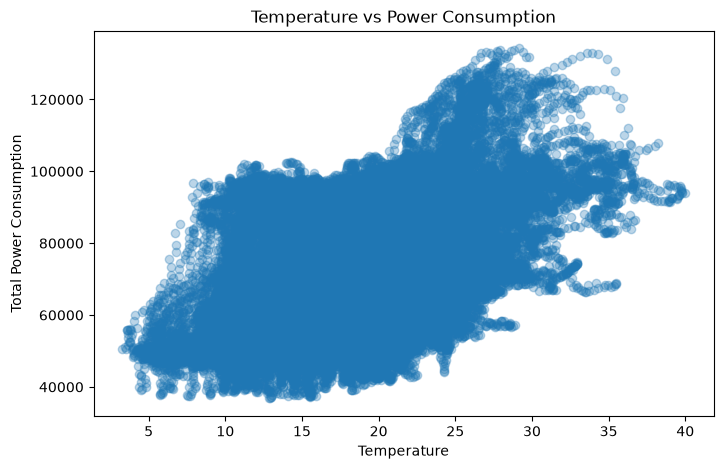

In [15]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Temperature'],
    df['Total_Power_Consumption'],
    alpha=0.3
)

plt.xlabel('Temperature')
plt.ylabel('Total Power Consumption')
plt.title('Temperature vs Power Consumption')

plt.show()